In [1]:
!kaggle datasets download jessicali9530/celeba-dataset
!pip -q install insightface onnxruntime-gpu
!pip -q install torchmetrics
!pip -q install torchmetrics[image]

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 22.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.6/85.6 kB 4.9 MB/s eta 0:00:00


In [ ]:
!unzip -q celeba-dataset.zip

In [ ]:
!cp "/content/drive/MyDrive/Colab_Notebooks/faces.zip" "/content/faces.zip"
!unzip -q faces.zip

In [2]:
import os
import cv2 as cv
import numpy as np
import polars as pl
import pandas as pd
from matplotlib import pyplot as plt
from tqdm.notebook import tqdm
from torch import nn
from torch.utils.data import Dataset, DataLoader
from torch.utils.data import random_split
from PIL import Image
import torchvision.utils as vutils
from torchvision import transforms
from torchmetrics.image.fid import FrechetInceptionDistance
from torchmetrics.image.inception import InceptionScore
import torch
import torch.nn.functional as F

# вырезание и выравнивание лиц

In [ ]:
img_path = "/content/img_align_celeba/img_align_celeba/"
images = [f"{image}" for image in os.listdir(img_path)]

In [ ]:
app = FaceAnalysis(providers=['CUDAExecutionProvider'])
app.prepare(ctx_id=0, det_size=(320, 320))

for image in tqdm(images):
    img = cv.imread(f"{img_path}{image}")
    faces = app.get(img)
    if len(faces) == 0:
        continue
    face = faces[0]
    align = face_align.norm_crop(img, landmark=face.kps, image_size=112)
    cv.imwrite(f"/content/faces/{image}", align)

Applied providers: ['CUDAExecutionProvider', 'CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}, 'CUDAExecutionProvider': {'sdpa_kernel': '0', 'use_tf32': '1', 'fuse_conv_bias': '0', 'prefer_nhwc': '0', 'tunable_op_max_tuning_duration_ms': '0', 'enable_skip_layer_norm_strict_mode': '0', 'tunable_op_tuning_enable': '0', 'tunable_op_enable': '0', 'use_ep_level_unified_stream': '0', 'device_id': '0', 'has_user_compute_stream': '0', 'gpu_external_empty_cache': '0', 'cudnn_conv_algo_search': 'EXHAUSTIVE', 'cudnn_conv1d_pad_to_nc1d': '0', 'gpu_mem_limit': '18446744073709551615', 'gpu_external_alloc': '0', 'gpu_external_free': '0', 'arena_extend_strategy': 'kNextPowerOfTwo', 'do_copy_in_default_stream': '1', 'enable_cuda_graph': '0', 'user_compute_stream': '0', 'cudnn_conv_use_max_workspace': '1'}}
find model: /root/.insightface/models/buffalo_l/1k3d68.onnx landmark_3d_68 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CUDAExecutionProvider', 'CPUExecutionProvider'], with o

  0%|          | 0/202599 [00:00<?, ?it/s]

# WGAN-GP

In [5]:
latent_dim = 100

In [ ]:
class Generator(nn.Module):
    def __init__(self, latent_dim=100, base_channels=32):
        super().__init__()
        self.latent_dim = latent_dim

        self.fc = nn.Sequential(
            nn.Linear(latent_dim, base_channels * 16 * 7 * 7),
            nn.BatchNorm1d(base_channels * 16 * 7 * 7),
            nn.ReLU(True)
        )

        self.net = nn.Sequential(
            nn.Upsample(scale_factor=2),
            nn.Conv2d(base_channels * 16, base_channels * 8, 3, 1, 1),
            nn.BatchNorm2d(base_channels * 8),
            nn.ReLU(True),

            nn.Upsample(scale_factor=2),
            nn.Conv2d(base_channels * 8, base_channels * 4, 3, 1, 1),
            nn.BatchNorm2d(base_channels * 4),
            nn.ReLU(True),

            nn.Upsample(scale_factor=2),
            nn.Conv2d(base_channels * 4, base_channels * 2, 3, 1, 1),
            nn.BatchNorm2d(base_channels * 2),
            nn.ReLU(True),

            nn.Conv2d(base_channels * 2, 3, 3, 1, 1),
            nn.Tanh()
        )

    def forward(self, z):
        z = z.view(z.size(0), self.latent_dim)
        x = self.fc(z)
        x = x.view(z.size(0), -1, 7, 7)
        return self.net(x)

class Critic(nn.Module):
    def __init__(self, base_channels=32):
        super().__init__()

        self.model = nn.Sequential(
            nn.Conv2d(3, base_channels, 4, 2, 1),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(base_channels, base_channels * 2, 4, 2, 1),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(base_channels * 2, base_channels * 4, 4, 2, 1),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Flatten(),
            nn.Linear(base_channels * 4 * 7 * 7, 1)
        )

    def forward(self, x):
        return self.model(x)

In [ ]:
def gradient_penalty(critic, real, fake, device="cuda", condition=False, label=None):
    BATCH_SIZE, C, H, W = real.shape
    epsilon = torch.rand((BATCH_SIZE, 1, 1, 1)).to(device)

    interpolate = (epsilon * real + (1 - epsilon) * fake).detach().requires_grad_(True)

    if condition:
        output = critic(interpolate, label)
    else:
        output = critic(interpolate)

    grad = torch.autograd.grad(
        outputs=output,
        inputs=interpolate,
        grad_outputs=torch.ones_like(output),
        create_graph=True,
        retain_graph=True,
    )[0].view(BATCH_SIZE, -1)
    norm = grad.norm(2, dim=1)

    return torch.mean((norm - 1) ** 2)

def update_fid_is(generator, fid_metric, is_metric, real, device="cuda", condition=False, label=None):
    real = real.to(device)
    batch_size = real.size(0)
    noise = torch.randn(batch_size, latent_dim, 1, 1, device=device)
    if condition:
        fake = generator(noise, label)
    else:
        fake = generator(noise)

    fake = ((fake.clamp(-1, 1) + 1) * 127.5).to(torch.uint8)
    real = ((real.clamp(-1, 1) + 1) * 127.5).to(torch.uint8)

    fid_metric.update(real, real=True)
    fid_metric.update(fake, real=False)

    is_metric.update(fake)

def save_generated(generator, epoch, device="cuda", condition=False):
    if condition:
        os.makedirs("generated/condition", exist_ok=True)
        noise = torch.randn(4, latent_dim, 1, 1, device=device)
        labels = torch.tensor([0, 1, 0, 1], device=device)
        fake = generator(noise, labels)
        fake = (fake + 1) / 2
        vutils.save_image(
            fake,
            f"generated/condition/epoch_{epoch+1}.jpg",
            nrow=2
        )
        return


    os.makedirs("generated/without_condition", exist_ok=True)
    noise = torch.randn(4, latent_dim, 1, 1, device=device)
    fake = generator(noise)
    fake = (fake + 1) / 2
    vutils.save_image(
        fake,
        f"generated/without_condition/epoch_{epoch+1}.jpg",
        nrow=2
    )

In [ ]:
class CelebA(Dataset):
    def __init__(self, img_path, transforms):
        super().__init__()
        self.images = [f"{image}" for image in os.listdir(img_path)]
        self.img_path = img_path
        self.transform = transforms

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img = cv.imread(f"{self.img_path}/{self.images[idx]}")
        img = cv.cvtColor(img, cv.COLOR_BGR2RGB)
        img = Image.fromarray(img)
        return self.transform(img)


transform = transforms.Compose([
    transforms.Resize((56, 56)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.5, 0.5, 0.5],
        std=[0.5, 0.5, 0.5]
        )
    ])

dataset = CelebA("faces", transform)
train_size = int(len(dataset) * 0.8)
val_size = len(dataset) - train_size
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

train_dataloader = DataLoader(train_dataset, batch_size=256, shuffle=True, num_workers=4)
val_dataloader = DataLoader(val_dataset, batch_size=256, shuffle=False, num_workers=4)

In [ ]:
def train(generator, critic, train_dataloader, val_dataloader, opt_gen, opt_critic, device="cuda"):
    generator = generator.to(device)
    critic = critic.to(device)
    FID = []
    IS = []
    lambda_gp = 10
    fid_metric = FrechetInceptionDistance().to(device)
    is_metric = InceptionScore().to(device)

    for epoch in range(50):
        print(f"=== EPOCH: {epoch + 1} ===")
        for real in tqdm(train_dataloader):
            generator.train()
            critic.train()
            real = real.to(device)

            for _  in range(3):
                noise = torch.randn(real.shape[0], latent_dim, 1, 1).to(device)
                fake = generator(noise).detach()

                critic_real = critic(real).reshape(-1)
                critic_fake = critic(fake).reshape(-1)
                gp = gradient_penalty(critic, real, fake, device=device)

                loss_critic = torch.mean(critic_fake) - torch.mean(critic_real) + lambda_gp * gp
                opt_critic.zero_grad()
                loss_critic.backward()
                opt_critic.step()

            noise = torch.randn(real.shape[0], latent_dim, 1, 1).to(device)
            fake = generator(noise)

            critic_fake = critic(fake).reshape(-1)

            loss_generator = -torch.mean(critic_fake)

            opt_gen.zero_grad()
            loss_generator.backward()
            opt_gen.step()

        generator.eval()

        fid_metric.reset()
        is_metric.reset()

        with torch.no_grad():
            for real in tqdm(val_dataloader):
                update_fid_is(generator, fid_metric, is_metric, real, device=device)

        fid_value = fid_metric.compute().item()
        is_value = is_metric.compute()[0].item()

        FID.append(fid_value)
        IS.append(is_value)

        save_generated(generator, epoch, device=device)

        print(f"FID: {fid_value:.2f} | IS: {is_value:.2f}")

    return FID, IS

In [ ]:
generator = Generator()
critic = Critic()
opt_gen = torch.optim.Adam(generator.parameters(), lr=1e-4, betas=(0.0, 0.9))
opt_critic = torch.optim.Adam(critic.parameters(), lr=1e-4, betas=(0.0, 0.9))
FID_WGAN, IS_WGAN = train(generator, critic, train_dataloader, val_dataloader, opt_gen, opt_critic, device='cuda')

=== EPOCH: 1 ===


/home/pong-ping/zalupa/.venv/lib/python3.12/site-packages/torchmetrics/utilities/prints.py:43: UserWarning: Metric `InceptionScore` will save all extracted features in buffer. For large datasets this may lead to large memory footprint.
  warnings.warn(*args, **kwargs)


  0%|          | 0/633 [00:00<?, ?it/s]

/home/pong-ping/zalupa/.venv/lib/python3.12/site-packages/torch/autograd/graph.py:869: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at /pytorch/aten/src/ATen/cuda/CublasHandlePool.cpp:335.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


  0%|          | 0/159 [00:00<?, ?it/s]

...

  0%|          | 0/159 [00:00<?, ?it/s]

FID: 18.29 | IS: 1.77
=== EPOCH: 50 ===


  0%|          | 0/633 [00:00<?, ?it/s]

  0%|          | 0/159 [00:00<?, ?it/s]

FID: 19.01 | IS: 1.81


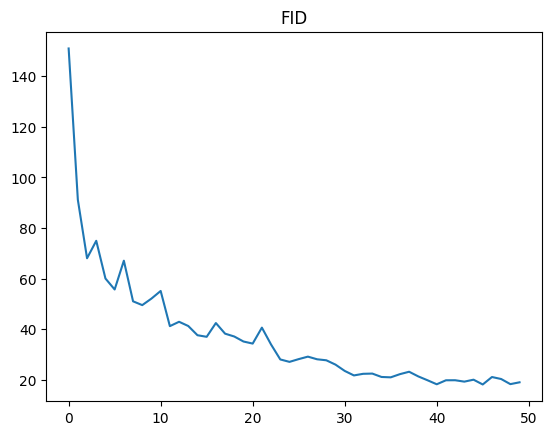

In [ ]:
plt.plot(FID_WGAN)
plt.title("FID")
plt.show()

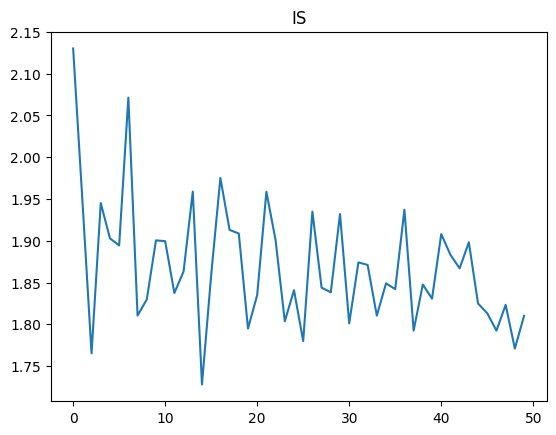

In [ ]:
plt.plot(IS_WGAN)
plt.title("IS")
plt.show()

# Conditional WGAN-GP

In [ ]:
df = pd.read_csv('list_attr_celeba.csv')
df = pl.from_pandas(df)
df

image_id,5_o_Clock_Shadow,Arched_Eyebrows,Attractive,Bags_Under_Eyes,Bald,Bangs,Big_Lips,Big_Nose,Black_Hair,Blond_Hair,Blurry,Brown_Hair,Bushy_Eyebrows,Chubby,Double_Chin,Eyeglasses,Goatee,Gray_Hair,Heavy_Makeup,High_Cheekbones,Male,Mouth_Slightly_Open,Mustache,Narrow_Eyes,No_Beard,Oval_Face,Pale_Skin,Pointy_Nose,Receding_Hairline,Rosy_Cheeks,Sideburns,Smiling,Straight_Hair,Wavy_Hair,Wearing_Earrings,Wearing_Hat,Wearing_Lipstick,Wearing_Necklace,Wearing_Necktie,Young
str,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64
"""000001.jpg""",-1,1,1,-1,-1,-1,-1,-1,-1,-1,-1,1,-1,-1,-1,-1,-1,-1,1,1,-1,1,-1,-1,1,-1,-1,1,-1,-1,-1,1,1,-1,1,-1,1,-1,-1,1
"""000002.jpg""",-1,-1,-1,1,-1,-1,-1,1,-1,-1,-1,1,-1,-1,-1,-1,-1,-1,-1,1,-1,1,-1,-1,1,-1,-1,-1,-1,-1,-1,1,-1,-1,-1,-1,-1,-1,-1,1
"""000003.jpg""",-1,-1,-1,-1,-1,-1,1,-1,-1,-1,1,-1,-1,-1,-1,-1,-1,-1,-1,-1,1,-1,-1,1,1,-1,-1,1,-1,-1,-1,-1,-1,1,-1,-1,-1,-1,-1,1
"""000004.jpg""",-1,-1,1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,1,-1,-1,1,-1,-1,-1,-1,1,-1,1,-1,1,1,-1,1
"""000005.jpg""",-1,1,1,-1,-1,-1,1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,1,-1,-1,-1,-1,1,1,-1,-1,1,-1,-1,-1,-1,-1,-1,-1,-1,1,-1,-1,1
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""202595.jpg""",-1,-1,1,-1,-1,-1,1,-1,-1,1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,1,-1,-1,1
"""202596.jpg""",-1,-1,-1,-1,-1,1,1,-1,-1,1,-1,-1,-1,-1,-1,-1,-1,-1,-1,1,1,1,-1,1,1,-1,1,-1,-1,-1,-1,1,1,-1,-1,-1,-1,-1,-1,1
"""202597.jpg""",-1,-1,-1,-1,-1,-1,-1,-1,1,-1,-1,-1,-1,-1,-1,1,-1,-1,-1,1,1,1,-1,-1,1,-1,-1,-1,-1,-1,-1,1,-1,-1,-1,-1,-1,-1,-1,1


In [ ]:
gender = df.select(["image_id", "Male"])
gender

image_id,Male
str,i64
"""000001.jpg""",-1
"""000002.jpg""",-1
"""000003.jpg""",1
"""000004.jpg""",-1
"""000005.jpg""",-1
…,…
"""202595.jpg""",-1
"""202596.jpg""",1
"""202597.jpg""",1


In [ ]:
gender = gender.with_columns(
    pl.col("Male").replace(-1, 0)
)
gender

image_id,Male
str,i64
"""000001.jpg""",0
"""000002.jpg""",0
"""000003.jpg""",1
"""000004.jpg""",0
"""000005.jpg""",0
…,…
"""202595.jpg""",0
"""202596.jpg""",1
"""202597.jpg""",1


In [ ]:
class ConditionalCelebA(Dataset):
    def __init__(self, genders: pl.DataFrame, img_path, transform) -> None:
        super().__init__()
        self.genders = genders
        self.img_path = img_path
        self.images = [f"{image}" for image in os.listdir(img_path)]
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img = cv.imread(f"{self.img_path}/{self.images[idx]}")
        img = cv.cvtColor(img, cv.COLOR_BGR2RGB)
        img = Image.fromarray(img)
        label = torch.tensor(self.genders.filter(pl.col("image_id") == self.images[idx])["Male"][0])
        return label, self.transform(img)

transform = transforms.Compose([
    transforms.Resize((56, 56)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.5, 0.5, 0.5],
        std=[0.5, 0.5, 0.5]
        )
    ])

dataset = ConditionalCelebA(gender, "faces", transform)
train_size = int(len(dataset) * 0.8)
val_size = len(dataset) - train_size
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

train_dataloader = DataLoader(train_dataset, batch_size=256, shuffle=True)
val_dataloader = DataLoader(val_dataset, batch_size=256, shuffle=False)

In [15]:
class CGenerator(nn.Module):
    def __init__(self, latent_dim=100, base_channels=32, num_classes=2):
        super().__init__()
        self.latent_dim = latent_dim
        self.num_classes = num_classes

        self.fc = nn.Sequential(
            nn.Linear(latent_dim + num_classes, base_channels * 16 * 7 * 7),
            nn.BatchNorm1d(base_channels * 16 * 7 * 7),
            nn.ReLU(True)
        )

        self.net = nn.Sequential(
            nn.Upsample(scale_factor=2),
            nn.Conv2d(base_channels * 16, base_channels * 8, 3, 1, 1),
            nn.BatchNorm2d(base_channels * 8),
            nn.ReLU(True),

            nn.Upsample(scale_factor=2),
            nn.Conv2d(base_channels * 8, base_channels * 4, 3, 1, 1),
            nn.BatchNorm2d(base_channels * 4),
            nn.ReLU(True),

            nn.Upsample(scale_factor=2),
            nn.Conv2d(base_channels * 4, base_channels * 2, 3, 1, 1),
            nn.BatchNorm2d(base_channels * 2),
            nn.ReLU(True),

            nn.Conv2d(base_channels * 2, 3, 3, 1, 1),
            nn.Tanh()
        )

    def forward(self, z ,y):
        z = z.view(z.size(0), self.latent_dim)
        y = F.one_hot(y, num_classes=self.num_classes).float().to(z.device)
        x = torch.cat([z, y], dim=1)
        x = self.fc(x)
        x = x.view(z.size(0), -1, 7, 7)
        return self.net(x)

class CCritic(nn.Module):
    def __init__(self, base_channels=32, num_classes=2):
        super().__init__()
        self.num_classes = num_classes

        self.model = nn.Sequential(
            nn.Conv2d(3 + num_classes, base_channels, 4, 2, 1),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(base_channels, base_channels * 2, 4, 2, 1),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(base_channels * 2, base_channels * 4, 4, 2, 1),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Flatten(),
            nn.Linear(base_channels * 4 * 7 * 7, 1)
        )

    def forward(self, x, y):
        y = F.one_hot(y, num_classes=self.num_classes).float().to(x.device)
        y = y[:, :, None, None]
        y = y.expand(-1, -1, x.size(2), x.size(3))
        x = torch.cat([x, y], dim=1)
        return self.model(x)

In [ ]:
def ctrain(generator, critic, train_dataloader, val_dataloader, opt_gen, opt_critic, device="cuda"):
    generator = generator.to(device)
    critic = critic.to(device)
    FID = []
    IS = []
    lambda_gp = 10
    fid_metric = FrechetInceptionDistance().to(device)
    is_metric = InceptionScore().to(device)

    for epoch in range(50):
        print(f"=== EPOCH: {epoch + 1} ===")

        total_loss_generator, total_loss_critic = 0, 0
        generator.train()
        critic.train()

        for label, real in tqdm(train_dataloader):
            real = real.to(device)
            label = label.to(device)

            for _  in range(3):
                noise = torch.randn(real.shape[0], latent_dim, 1, 1).to(device)
                fake = generator(noise, label).detach()

                critic_real = critic(real, label).reshape(-1)
                critic_fake = critic(fake, label).reshape(-1)
                gp = gradient_penalty(critic, real, fake, device=device, condition=True, label=label)

                loss_critic = torch.mean(critic_fake) - torch.mean(critic_real) + lambda_gp * gp
                opt_critic.zero_grad()
                loss_critic.backward()
                opt_critic.step()

            noise = torch.randn(real.shape[0], latent_dim, 1, 1).to(device)
            fake = generator(noise, label)

            critic_fake = critic(fake, label).reshape(-1)

            loss_generator = -torch.mean(critic_fake)

            opt_gen.zero_grad()
            loss_generator.backward()
            opt_gen.step()

            total_loss_generator += loss_generator.item()
            total_loss_critic += loss_critic.item()

        generator.eval()

        fid_metric.reset()
        is_metric.reset()

        with torch.no_grad():
            for label, real in tqdm(val_dataloader):
                update_fid_is(generator, fid_metric, is_metric, real, device=device, condition=True, label=label)

        fid_value = fid_metric.compute().item()
        is_value = is_metric.compute()[0].item()

        FID.append(fid_value)
        IS.append(is_value)

        save_generated(generator, epoch, device=device, condition=True)

        avg_generator_loss = total_loss_generator / len(train_dataloader)
        avg_critic_loss = total_loss_critic / len(train_dataloader)

        print(f"FID: {fid_value:.2f} | IS: {is_value:.2f}")
        print(f"Generator loss: {avg_generator_loss:.3f} | Critic loss: {avg_critic_loss:.3f}")

    return FID, IS

In [ ]:
generator = CGenerator()
critic = CCritic()
opt_gen = torch.optim.Adam(generator.parameters(), lr=1e-4, betas=(0.0, 0.9))
opt_critic = torch.optim.Adam(critic.parameters(), lr=1e-4, betas=(0.0, 0.9))
FID_CWGAN, IS_CWGAN = ctrain(generator, critic, train_dataloader, val_dataloader, opt_gen, opt_critic, device='cuda')

=== EPOCH: 1 ===


/home/pong-ping/zalupa/.venv/lib/python3.12/site-packages/torchmetrics/utilities/prints.py:43: UserWarning: Metric `InceptionScore` will save all extracted features in buffer. For large datasets this may lead to large memory footprint.
  warnings.warn(*args, **kwargs)


  0%|          | 0/633 [00:00<?, ?it/s]

/home/pong-ping/zalupa/.venv/lib/python3.12/site-packages/torch/autograd/graph.py:869: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at /pytorch/aten/src/ATen/cuda/CublasHandlePool.cpp:335.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


  0%|          | 0/159 [00:00<?, ?it/s]

...

  0%|          | 0/159 [00:00<?, ?it/s]

FID: 72.46 | IS: 2.09
Generator loss: -42.181 | Critic loss: -0.048
=== EPOCH: 50 ===


  0%|          | 0/633 [00:00<?, ?it/s]

  0%|          | 0/159 [00:00<?, ?it/s]

FID: 77.53 | IS: 2.28
Generator loss: -46.973 | Critic loss: -0.028


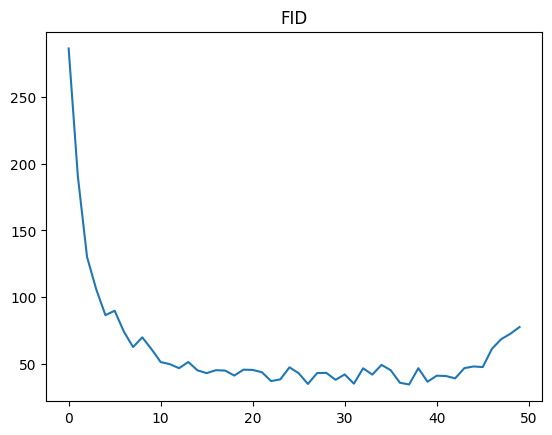

In [ ]:
plt.plot(FID_CWGAN)
plt.title("FID")
plt.show()

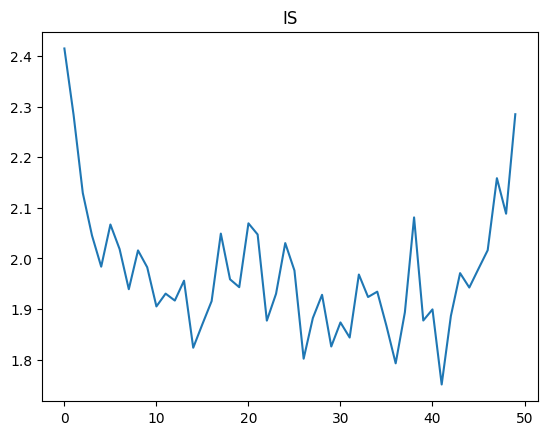

In [ ]:
plt.plot(IS_CWGAN)
plt.title("IS")
plt.show()

In [ ]:
torch.save(critic.state_dict(), 'critic_condition.pt')

In [ ]:
torch.save(critic.state_dict(), 'critic_condition.pt')

### Проверка, что из одного вектора шума с разными метками получаются разные изображения

In [3]:
def show_tensor(img):
    img = img.detach().cpu()
    img = img.squeeze(0)
    img = img.permute(1, 2, 0)

    plt.imshow(img)
    plt.axis("off")
    plt.show()

In [16]:
device = 'cuda'
generator = CGenerator(latent_dim=100, base_channels=32, num_classes=2)
state_dict = torch.load('generator_condition.pt', map_location=device)
generator.load_state_dict(state_dict)
generator.to(device)
generator.eval()

with torch.no_grad():
    noise = torch.randn(1, latent_dim, device=device)
    label = torch.tensor([0], device=device)
    fake_female = generator(noise, label)
    fake_female = (fake_female + 1) / 2
    label = torch.tensor([1], device=device)
    fake_male = generator(noise, label)
    fake_male = (fake_male + 1) / 2

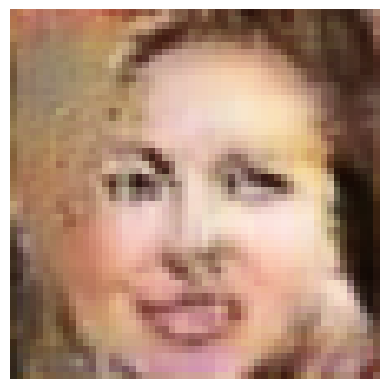

In [17]:
show_tensor(fake_female)

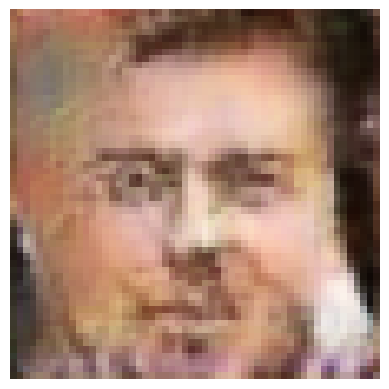

In [18]:
show_tensor(fake_male)